# 이상 탐지 모델링 — 3주차

`X_test`는 최종 성능 보고에만 1회 사용하고, 그 전 어떤 튜닝에도 쓰지 않는다.

1. `dev = train_raw + val` (원본 비율, real ratio)를 구성
2. XGBoost 분류 임계값을 **5-fold 교차검증 OOF(out-of-fold) 예측**으로 튜닝 — 단일 val split은 양성 샘플이 너무 적어(~17개) 임계값 추정이 불안정하므로, dev 전체(83개 양성)를 순환시켜 안정적인 임계값을 구한다
3. 최종 XGBoost는 `dev`를 SMOTE로 균형 맞춘 뒤 전량 재학습
4. Isolation Forest(비지도)는 `dev`(원본 비율)로 학습
5. 앙상블: 두 모델 중 하나라도 이상 판정 시 알림 (민감도 우선)
6. `X_test`로 세 가지(IF / XGBoost / 앙상블) 최종 성능 비교, 모델과 임계값을 `models/`에 저장

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
RANDOM_STATE = 42

XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

## 1. 데이터 로드 및 dev 셋 구성

In [2]:
X_train_raw = pd.read_csv(f"{DATA_DIR}/X_train_raw.csv")
y_train_raw = pd.read_csv(f"{DATA_DIR}/y_train_raw.csv").squeeze("columns")

X_val = pd.read_csv(f"{DATA_DIR}/X_val.csv")
y_val = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze("columns")

X_test = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns")

X_dev = pd.concat([X_train_raw, X_val], ignore_index=True)
y_dev = pd.concat([y_train_raw, y_val], ignore_index=True)

print("X_dev (train+val, 원본 비율):", X_dev.shape, dict(y_dev.value_counts()))
print("X_test:", X_test.shape, dict(y_test.value_counts()))

X_dev (train+val, 원본 비율): (1253, 440) {0: np.int64(1170), 1: np.int64(83)}
X_test: (314, 440) {0: np.int64(293), 1: np.int64(21)}


## 2. Isolation Forest (비지도)

`X_dev`(원본 비율, 라벨 미사용)로 학습. `contamination=0.07`은 SECOM 실제 불량률(6.64%)에 근접한 값.

In [3]:
if_model = IsolationForest(
    n_estimators=200,
    contamination=0.07,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
if_model.fit(X_dev)

# predict: 1=정상, -1=이상 -> 1=이상(fail)으로 통일
if_pred_test = (if_model.predict(X_test) == -1).astype(int)

# decision_function: 낮을수록 이상치에 가까움 -> 부호를 뒤집어 '높을수록 이상' 스코어로 변환
if_score_test = -if_model.decision_function(X_test)

## 3. XGBoost 임계값 튜닝 — 5-fold OOF

각 fold에서: (k-1)/5 만큼을 SMOTE로 균형 맞춰 학습하고, 나머지 1/5(원본 비율)에 대해 예측 확률을 낸다. 이렇게 모은 OOF 확률(`X_dev` 전체, 양성 83개)로 F1을 최대화하는 임계값을 고른다. **test는 이 과정에 전혀 등장하지 않는다.**

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y_dev))

for fold, (tr_idx, ho_idx) in enumerate(skf.split(X_dev, y_dev), 1):
    X_tr, y_tr = X_dev.iloc[tr_idx], y_dev.iloc[tr_idx]
    X_ho = X_dev.iloc[ho_idx]

    X_tr_res, y_tr_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    fold_model = XGBClassifier(**XGB_PARAMS)
    fold_model.fit(X_tr_res, y_tr_res)

    oof_proba[ho_idx] = fold_model.predict_proba(X_ho)[:, 1]
    print(f"fold {fold} done — holdout positives: {int(y_dev.iloc[ho_idx].sum())}")

prec_o, rec_o, thr_o = precision_recall_curve(y_dev, oof_proba)
f1_o = 2 * prec_o * rec_o / (prec_o + rec_o + 1e-9)
best_idx = f1_o[:-1].argmax()
best_threshold = float(thr_o[best_idx])

print(f"\nOOF 기준 최적 임계값: {best_threshold:.4f} (OOF F1={f1_o[best_idx]:.4f}, AUROC={roc_auc_score(y_dev, oof_proba):.4f})")

fold 1 done — holdout positives: 17


fold 2 done — holdout positives: 17


fold 3 done — holdout positives: 17


fold 4 done — holdout positives: 16


fold 5 done — holdout positives: 16

OOF 기준 최적 임계값: 0.0474 (OOF F1=0.2339, AUROC=0.6861)


## 4. 최종 XGBoost 학습

`X_dev` 전체를 SMOTE로 균형 맞춰 재학습 (OOF 단계보다 더 많은 데이터로 최종 모델을 만든다).

In [5]:
X_dev_res, y_dev_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_dev, y_dev)
xgb_model = XGBClassifier(**XGB_PARAMS)
xgb_model.fit(X_dev_res, y_dev_res)

xgb_proba_test = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred_test = (xgb_proba_test >= best_threshold).astype(int)

### 피처 중요도 상위 20개

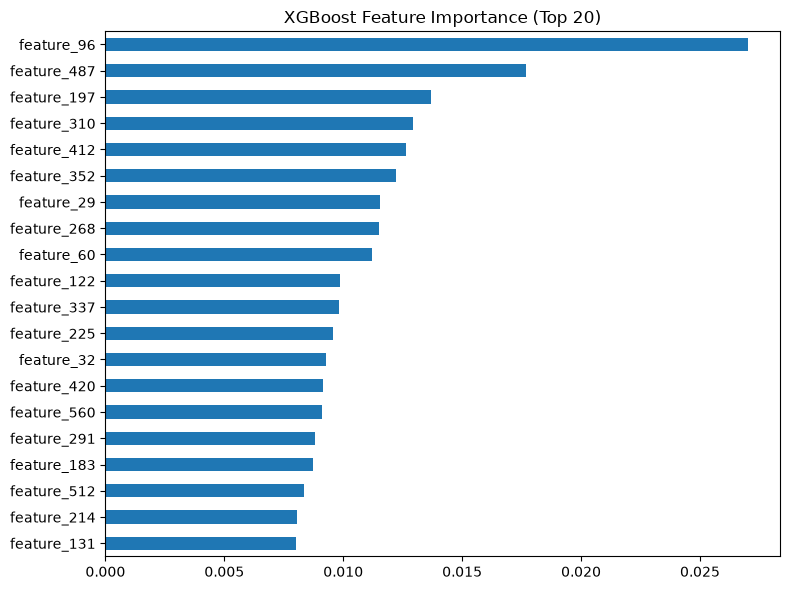

In [6]:
importances = pd.Series(xgb_model.feature_importances_, index=X_dev.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
top20[::-1].plot(kind="barh")
plt.title("XGBoost Feature Importance (Top 20)")
plt.tight_layout()
plt.show()

## 5. 앙상블

- **투표(민감도 우선)**: IF 또는 XGBoost 둘 중 하나라도 이상 판정 시 최종 이상으로 알림
- **가중 평균 스코어**: 두 모델의 이상 스코어를 0~1로 정규화 후 평균 (AUROC 비교용)

In [7]:
# 투표 방식
ensemble_pred = ((if_pred_test == 1) | (xgb_pred_test == 1)).astype(int)

# 가중 평균 스코어 방식 (0~1 정규화 후 단순 평균)
scaler = MinMaxScaler()
if_score_norm = scaler.fit_transform(if_score_test.reshape(-1, 1)).ravel()
ensemble_score = 0.5 * if_score_norm + 0.5 * xgb_proba_test

## 6. 성능 비교 (test, 최초 1회 평가)

In [8]:
def summarize(name, y_true, y_pred, y_score):
    return {
        "model": name,
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "auroc": round(roc_auc_score(y_true, y_score), 4),
    }

results = pd.DataFrame([
    summarize("Isolation Forest", y_test, if_pred_test, if_score_test),
    summarize("XGBoost", y_test, xgb_pred_test, xgb_proba_test),
    summarize("Ensemble (vote + score)", y_test, ensemble_pred, ensemble_score),
])
results

,model,precision,recall,f1,auroc
0,Isolation Forest,0.2143,0.1429,0.1714,0.5407
1,XGBoost,0.1552,0.4286,0.2278,0.6919
2,Ensemble (vote + score),0.1562,0.4762,0.2353,0.6119


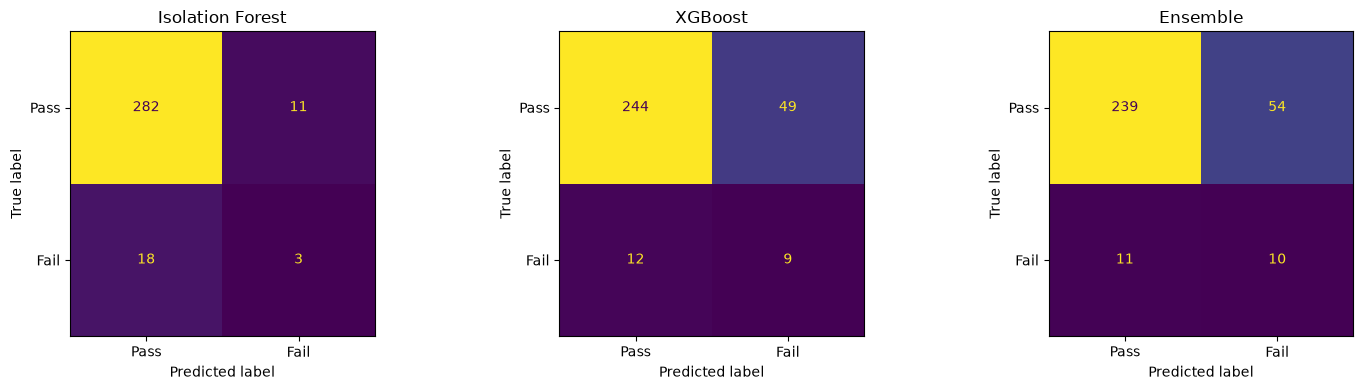

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(
    axes,
    [("Isolation Forest", if_pred_test), ("XGBoost", xgb_pred_test), ("Ensemble", ensemble_pred)],
):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Pass", "Fail"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [10]:
print("=== XGBoost classification report ===")
print(classification_report(y_test, xgb_pred_test, target_names=["Pass", "Fail"]))
print("=== Ensemble classification report ===")
print(classification_report(y_test, ensemble_pred, target_names=["Pass", "Fail"]))

=== XGBoost classification report ===
              precision    recall  f1-score   support

        Pass       0.95      0.83      0.89       293
        Fail       0.16      0.43      0.23        21

    accuracy                           0.81       314
   macro avg       0.55      0.63      0.56       314
weighted avg       0.90      0.81      0.84       314

=== Ensemble classification report ===
              precision    recall  f1-score   support

        Pass       0.96      0.82      0.88       293
        Fail       0.16      0.48      0.24        21

    accuracy                           0.79       314
   macro avg       0.56      0.65      0.56       314
weighted avg       0.90      0.79      0.84       314



## 7. 모델 저장

In [11]:
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(if_model, f"{MODELS_DIR}/isolation_forest.joblib")
joblib.dump(xgb_model, f"{MODELS_DIR}/xgboost.joblib")
joblib.dump(list(X_dev.columns), f"{MODELS_DIR}/feature_columns.joblib")
joblib.dump(best_threshold, f"{MODELS_DIR}/xgboost_threshold.joblib")
results.to_csv(f"{MODELS_DIR}/model_comparison.csv", index=False)
print("저장 완료:", sorted(os.listdir(MODELS_DIR)))

저장 완료: ['.gitkeep', 'feature_columns.joblib', 'isolation_forest.joblib', 'model_comparison.csv', 'xgboost.joblib', 'xgboost_threshold.joblib']


## 다음 단계

- 4주차: FastAPI 서버(`backend/`)에서 `models/isolation_forest.joblib`, `models/xgboost.joblib`, `models/xgboost_threshold.joblib`을 로드해 `/api/ai/detect` 엔드포인트 구현
- (선택, 6주차 이후) LSTM Autoencoder 추가